# WGAN_GP 
Andrew E. Davidson aedavids@ucsc.edu 8/29/24  

Copyright (c) 2020-2023, Regents of the University of California All rights reserved.   https://polyformproject.org/licenses/noncommercial/1.0.0

This notebook's purpose is to ensure the correctness of our PyTorch implementation. Our test generator learns to create points on a parabola. We have an infinite number of real training examples and can easily verify the results with a simple plot.

Most GANs train the discriminator using a binary cross-entropy loss function. This forces the discriminator to output either zero or one. This can lead to mode collapse and vanishing gradients.

We replaced the discriminator in basicPytorchGAN.ipynb with a Wasserstein critic and loss. The Wasserstein loss is unbounded and based on the "Earth Mover's Distance." The norm of the gradient of the Wasserstein critic must be 1-Lipschitz continuous, ensuring it is differentiable and grows linearly. This constraint is implemented using a penalty term on the gradient.

**Critic Loss**

$
L_C = \mathbb{E}_{x_{\text{real}} \sim p_{\text{data}}}[D(x_{\text{real}})] - \mathbb{E}_{x_{\text{fake}} \sim p_g}[D(x_{\text{fake}})]
$

Where:  
* $\mathbb{E}$ is the Expected value function
* D(x) is the critic's output for input x
* $p_{\text{data}}$ The distribution of real data
* $p_{\text{g}}$ The distribution of generated data






---
<span style="background:yellow;color:red">wrong equations</span>  

$\begin{equation}
L = \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g} [C(\tilde{x})] - \mathbb{E}_{x \sim \mathbb{P}_r} [C(G(z))] + \lambda \, \mathbb{E}_{\hat{x} \sim \mathbb{P}_{\hat{x}}} \left[ \left(\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1\right)^2 \right]
\end{equation}
$

Where:
* L is the loss
* $\mathbb{E}$ is the Expected value function
* C(x) is the critic
* G(z) is the generator
* z is the noise vector
* $\lambda$ is the graient penality coefficient
* $\hat{x}$ is a generated example
* $\tilde{x}$ is a real example
---

Note the basicPytorchGAN archtecture did not work with Wasserstein loss. We had to add capacity to both the generator and the critic to get this to work. Both basicPytorchGAN and WGAN_GP produce good results in 100k training steps

**ref:**  
- [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- [Improved Training of Wasserstein GANs](https://arxiv.org/abs/1704.00028)
- [pytorch doc](https://pytorch.org/docs/stable/index.html)
- basicPytorchGAN.ipynb

installed following to get rid of warning
```
https://ipywidgets.readthedocs.io/en/stable/user_install.html
conda install -c conda-forge jupyterlab_widgets
conda install -c conda-forge ipywidgets

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
```

In [1]:
import ipynbname
import matplotlib.pyplot as plt

from numpy import hstack
from numpy import zeros
from numpy import ones
import psutil # provides process stats
from numpy.random import rand
from numpy.random import randn
import os

# by default keras use tensorflow as backend
import torch
print(f'torch.__version__: {torch.__version__}')

from torch import nn
torch.manual_seed(0) # Set for testing purposes, 

# tqdm provides progress bars for loops and iterables.
from tqdm.auto import tqdm

# class that helps you efficiently load and iterate over your dataset
# during training or inference
# we do not need this for our toy example
from torch.utils.data import DataLoader

notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True) 
print(f'imgOut:\n{imgOut}')

torch.__version__: 2.5.1.post102
imgOut:
/private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img


## Create models

In [2]:
def generateLatentPoints(latentDimensions : int = 5, 
                         n : int = 100, device : str = 'cpu' ) -> torch.Tensor :
    '''
    generate points in latent space as input for the generator

    latentDimensions:
        the number of dimensions for the generator's input vector

    n the number of vectors to generate

    device. either 'cpu' or 'cuda', default 'cpu'


    returns a tensor
    '''
    # generate points in the latent space
    xInput = randn(latentDimensions * n)
    
    # reshape into a batch of inputs for the network
    xInput = xInput.reshape(n, latentDimensions)
    
    ret = torch.Tensor( xInput ).to( device )
    
    return ret

def testGenerateLatentPoints():
    tglp = generateLatentPoints(latentDimensions=5, n=3 )
    print(f'tglp.device : {str(tglp.device)}')
    print( tglp )
    print( tglp.shape )

testGenerateLatentPoints()

tglp.device : cpu
tensor([[-0.2142, -0.1663,  0.3299,  0.0972, -0.6664],
        [-0.7370, -2.4035, -1.6482,  0.4768,  0.0851],
        [-2.0320, -1.3007,  0.1606,  1.1425,  1.4369]])
torch.Size([3, 5])


In [3]:
class ParabolaGenerator( nn.Module ):
    def __init__( self, latentDim : int, nOutputs : int = 2 ) :
        '''
        arguments:
            latentDim: the length of the noise input vector

            nOutputs : the length of the output layers vector. Default = 2
        '''
        super().__init__()


        # keras
        # model.add(Dense(15, activation='relu', kernel_initializer='he_uniform', input_dim=latent_dim))
        # model.add(Dense(n_outputs, activation='linear'))
        
        self.model = nn.Sequential(
            nn.Linear(latentDim, 15),
            nn.ReLU(),

            # 11/12 add more capacity
            nn.Linear(15, 30),
            nn.ReLU(), 
            
            # nn.Linear(15, nOutputs),
            nn.Linear(30, nOutputs),
        )
        # Initialize weights
        # nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        # nn.init.zeros_(self.model[0].bias)
        # nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='linear')
        # nn.init.zeros_(self.model[2].bias)
        
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)

        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[2].bias)        
        
        nn.init.kaiming_uniform_(self.model[4].weight, nonlinearity='linear')
        nn.init.zeros_(self.model[4].bias)    

    def forward( self, noise : torch.Tensor ):
        '''
            noise should be the value returned by generateLatentPoints()
        '''
        ret = self.model( noise )
        return ret

def testParabolaGenerator():
    zDim = 5
    currentBatchSize = 3
    noiseVector = generateLatentPoints(zDim, currentBatchSize)
    generator = ParabolaGenerator(zDim, 2)
    fakeSamples = generator( noiseVector )
    print(f'fakeSamples:\n{fakeSamples}')

testParabolaGenerator()

fakeSamples:
tensor([[-0.1238,  0.8288],
        [-0.5132,  0.5375],
        [-2.0468, -0.6103]], grad_fn=<AddmmBackward0>)


In [4]:
class ParabolaCritic( nn.Module ):
    def __init__( self, inputSize : int = 2 ):
        '''
            inputSize, the length of the generated vectors
        '''
        super().__init__()

        # keras
        # model = Sequential()
    	# model.add(Dense(25, activation='relu', kernel_initializer='he_uniform', input_dim=n_inputs))
    	# model.add(Dense(1, activation='sigmoid'))
        
        self.model = nn.Sequential(
            nn.Linear(inputSize, 25),
            nn.ReLU(),
            
            nn.Linear(25, 40),
            # 11/12/24 add capacity
            nn.ReLU(),

            nn.Linear(40, 1),

            # output layer should be  1-Lipschitz continuous
            #nn.Sigmoid()
            # LeakyReLU default: negative_slope=0.01
            # 0.02 0.04
            nn.LeakyReLU(negative_slope=0.03, inplace=True)  # LeakyReLU instead of Sigmoid

        )
        
        # Initialize weights
        # nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        # nn.init.zeros_(self.model[0].bias)
        # nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='leaky_relu')
        # nn.init.zeros_(self.model[2].bias)

        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)

        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[2].bias)        
        
        nn.init.kaiming_uniform_(self.model[4].weight, nonlinearity='leaky_relu')
        nn.init.zeros_(self.model[4].bias)    

    def forward( self, X : torch.Tensor ):
        ret = self.model( X )
        return ret

def testParabolaCritic() :
    inputSize = 2
    discriminator = ParabolaCritic( inputSize )
    numTest = 3
    testInput = torch.randn( numTest, inputSize )
    predictions = discriminator( testInput )
    print(f'\npredictions :\n{predictions}')

testParabolaCritic()


predictions :
tensor([[-0.0091],
        [-0.0287],
        [-0.0368]], grad_fn=<LeakyReluBackward1>)


## Data Utilities
function to generate real and fake tensors

In [5]:
def generateRealSamples( n : int, device : str = 'cpu' ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    generate n real parabola samples with class labels

    arguments :
        n : number of examples to generated

        device. either 'cpu' or 'cuda', default 'cpu'

    Returns 2 Tensor
        X, y i.e. (realSamples, realLabels)

        y = 1, ie real
    '''
    # generate inputs in range [-0.5, 0.5]
    X1 = rand(n) - 0.5
    
    # generate outputs X^2
    X2 = X1 * X1
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    X = hstack((X1, X2))
    
    # generate class labels
    y = ones((n, 1))

    # numpy dtype defaults to float64
    # pytorch default is float32
    realSamples = torch.tensor( X, dtype=torch.float32 ).to( device )
    realLabels = torch.tensor( y, dtype=torch.float32 ).to( device )
    
    return (realSamples, realLabels)

def testGenerateRealSamples() :
    X, y = generateRealSamples( n = 10 ) 
    print(f'X.device : {str(X.device)}')
    print( f'X.shape: {X.shape} rank : {len(X.shape)} num elements : {X.numel()}' )
    print( X )

    print(f'\ny.device : {str(y.device)}')
    print( f'y.shape: {y.shape} rank : {len(y.shape)} num elements : {y.numel()}' )
    print ( y) 

testGenerateRealSamples()

X.device : cpu
X.shape: torch.Size([10, 2]) rank : 2 num elements : 20
tensor([[ 8.2765e-02,  6.8501e-03],
        [ 4.7816e-01,  2.2863e-01],
        [-2.4428e-01,  5.9671e-02],
        [ 3.8118e-02,  1.4530e-03],
        [ 3.5107e-01,  1.2325e-01],
        [ 1.7025e-01,  2.8985e-02],
        [-1.7208e-01,  2.9611e-02],
        [ 3.3616e-01,  1.1300e-01],
        [ 3.8262e-01,  1.4640e-01],
        [ 6.3010e-03,  3.9703e-05]])

y.device : cpu
y.shape: torch.Size([10, 1]) rank : 2 num elements : 10
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [6]:
def generateFakeSamples(generator : ParabolaGenerator, 
                        latentDimensions : int,
                        n : int,
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor]:
    '''
    use the generator to generate n fake examples, with class labels

    gradient calculation is disabled. (should run faster)

    device. either 'cpu' or 'cuda', default 'cpu'


    returns (fakeSamples, fakeLabels)
        labels will be zeros.
    '''
    # generate points in latent space
    noiseVector = generateLatentPoints(latentDimensions, n)

    # Set the model to evaluation mode
    # Layers like Dropout and Batch Normalization behave differently during 
    # training and evaluation.
    #
    # we do not need to worry about this. It a good future proofing code example
    generator.eval()

    # Disable gradient calculation for inference
    with torch.no_grad():
        fakeSamples = generator(noiseVector)
    
    # create class labels  
    y = zeros((n, 1))
    fakeLabels = torch.Tensor( y ).to( device )
    
    return fakeSamples, fakeLabels

def testGenerateFakeSamples():
    latentDimensions = 5
    numOutputs = 2
    

    gen = ParabolaGenerator( latentDimensions, numOutputs )

    numSamples = 3
    fakeSamples, fakeLabels = generateFakeSamples( gen, latentDimensions, numSamples)

    print( f'\nfakeSamples.shape: {fakeSamples.shape} rank : {len(fakeSamples.shape)} num elements : {fakeSamples.numel()}' )
    print(f'fakeSamples.device : {str(fakeSamples.device)}')

    print( fakeSamples )

    print( f'\nfakeLabels.shape: {fakeLabels.shape} rank : {len(fakeLabels.shape)} num elements : {fakeLabels.numel()}' )
    print(f'fakeLabels.device : {str(fakeLabels.device)}')
    
    print ( fakeLabels ) 


testGenerateFakeSamples()


fakeSamples.shape: torch.Size([3, 2]) rank : 2 num elements : 6
fakeSamples.device : cpu
tensor([[ 0.7033, -0.1772],
        [ 0.6091,  0.1241],
        [ 0.3193, -0.0979]])

fakeLabels.shape: torch.Size([3, 1]) rank : 2 num elements : 3
fakeLabels.device : cpu
tensor([[0.],
        [0.],
        [0.]])


## Train Model

In [7]:
def getGradient(crit, real, fake, epsilon):
    '''
    Return the gradient of the critic's scores with respect to mixes of real and fake examples.
    Parameters:
        crit: the critic model
        real: a batch of real examples
        fake: a batch of fake examples
        epsilon: a vector of the uniformly random proportions of real/fake per mixed image
    Returns:
        gradient: the gradient of the critic's scores, with respect to the mixed image
    '''
    # Mix the images together
    mixedImages = real * epsilon + fake * (1 - epsilon)

    # Calculate the critic's scores on the mixed images
    mixedScores = crit(mixedImages)
    
    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        # Note: You need to take the gradient of outputs with respect to inputs.
        # This documentation may be useful, but it should not be necessary:
        # https://pytorch.org/docs/stable/autograd.html#torch.autograd.grad
        inputs=mixedImages,
        outputs=mixedScores,
        
        # These other parameters have to do with the pytorch autograd engine works
        grad_outputs=torch.ones_like(mixedScores), 
        create_graph=True,
        retain_graph=True,
    )[0]
    return gradient

In [8]:
def gradientPenalty(gradient):
    '''
    Return the gradient penalty, given a gradient.
    Given a batch of examples gradients, calculate the magnitude of each example's gradient
    and penalize the mean quadratic distance of each magnitude to 1.
    Parameters:
        gradient: the gradient of the critic's scores, with respect to the mixed examples
    Returns:
        penalty: the gradient penalty
    '''
    # Flatten the gradients so that each row captures one image
    gradient = gradient.view(len(gradient), -1)

    # Calculate the magnitude of every row
    gradientNorm = gradient.norm(2, dim=1)
    
    # Penalize the mean squared distance of the gradient norms from 1
    penalty = torch.mean(gradientNorm - 1.0) ** 2
    
    return penalty

In [9]:
# def getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
#                          n, zDim, device) -> torch.Tensor:
#     '''
#     Return the loss of the discriminator on real and fake samples.
    
#     Parameters:
#         generator: the generator model, which returns an image given z-dimensional noise
        
#         discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
#         criterion: the loss function, which should be used to compare 
#                the discriminator's predictions to the ground truth reality of the images 
#                (e.g. fake = 0, real = 1)
               
#         real: a batch of real samples
        
#         n: the number of fakes the generator should produce, 
#                 which is also the length of the real images
                
#         zDim: the dimension of the noise vector, a scalar
        
#         device: the device type
        
#     Returns:
#         discriminatorLoss: a torch scalar loss value for the current batch
#     '''
#     # generate some fake samples
#     fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, n, device )

#     # get discriminator's prediction of the fake samples
#     # forward
#     predictionsOnFakes = discriminator( fakeSamples )
    
#     # calculate the loss on fakes
#     expected = torch.zeros(n, 1, device=device)  # All weights are equal to 0, ie fake
#     discriminatorLossOnFake = criterion(predictionsOnFakes, expected) 
   
#     # calculate loss on real samples
#     predictionsOnReal = discriminator( realSamples )
#     expected = torch.ones(n, 1, device=device)  # All weights are equal to 1, ie real
#     discriminatorLossOnReal = criterion(predictionsOnReal, expected) 
   
#     # calculate the average loss
#     discriminatorLoss = (discriminatorLossOnReal + discriminatorLossOnFake) / 2
    
#     return discriminatorLoss

In [10]:
def getGeneratorLoss(criticFakePredictions):
    '''
    Return the loss of a generator given the critic's scores of the generator's fake examples.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
    Returns:
        genertorLoss: a scalar loss value for the current batch of the generator
    '''
    genertorLoss = torch.mean( -1.0 * criticFakePredictions)

    return genertorLoss

In [11]:
def getCriticLoss(criticFakePredictions, criticRealPredicted, gp, criticLambda):
    '''
    Return the loss of a critic given the critic's scores for fake and real images,
    the gradient penalty, and gradient penalty weight.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
        criticRealPredicted: the critic's scores of the real images
        gp: the unweighted gradient penalty
        criticLambda: the current weight of the gradient penalty 
    Returns:
        crit_loss: a scalar for the critic's loss, accounting for the relevant factors
    '''
    # this is funky
    # notes say the loss is calculated by maximizing the distance between 
    # eq is mean(real) - mean(fake)
    # pytorch only minimizes so we we use mean(fake) - mean(real)
    crit_loss = torch.mean( criticFakePredictions ) \
                                    - torch.mean( criticRealPredicted ) \
                                    + (criticLambda * gp) 

    return crit_loss


In [12]:
# def testGetDiscriminatorLossSample() :
#     zDim = 5 # length of noise vector
#     exampleLength = 2 # X,Y
#     device = 'cpu'
#     batchSize = 4

#     generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
#     discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
#     criterion = nn.BCEWithLogitsLoss()

#     realSamples, realLabels = generateRealSamples( batchSize, device )
    
#     discriminatorLoss = getDiscriminatorLoss(generator, discriminator, criterion, 
#                                              realSamples, batchSize,
#                                               zDim, device)

#     print( f'discriminator loss : {discriminatorLoss}') 

# testGetDiscriminatorLossSample()

In [13]:
# def getGeneratorLoss(generator, discriminator, criterion, 
#                      n, zDim, device) -> torch.Tensor:
#     '''
#     The generator never sees real samples. Loss is
#     calculated only on fake samples

#         Parameters:
#         generator: the generator model, which returns an image given z-dimensional noise
        
#         discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
#         criterion: the loss function, which should be used to compare 
#                the discriminator's predictions to the ground truth reality of the images 
#                (e.g. fake = 0, real = 1)
               
#         n: the number of fakes the generator should produce, 
                
#         zDim: the dimension of the noise vector, a scalar
        
#         device: the device type
        
#     Returns:
#         generatorLoss: a torch scalar loss value for the current batch
#     '''
#     noiseVector = generateLatentPoints(zDim, n, device)

#     # forward() is the old way of doing things it breaks the grader
#     #fakeImgs = gen.forward(noiseVector)
#     fakeSamples = generator(noiseVector)
    
#     # forward() is the old way of doing things     
#     # predictionsOnFake = disc.forward( fakeImgs ).detach()
#     predictionsOnFake = discriminator( fakeSamples )#.detach()
    
#     # we are trying to trick the discriminator into thinking
#     # the fakes are real
#     expected = torch.ones(n, 1, device=device)  
#     generatorLoss = criterion(predictionsOnFake, expected) 
#     #     print(f'\nAEDWIP type(generatorLoss): {type(generatorLoss)}')
#     #     print(f'AEDWIP generatorLoss.shape: {generatorLoss.shape}')
#     #     print(f'AEDWIP generatorLoss: {generatorLoss}')   

#     return generatorLoss

In [14]:
# def summarizePerformance(epoch, generator, discriminator, latentDim, n=100):
def summarizePerformance( generator : ParabolaGenerator, 
                         latentDimensions : int,
                         outDir : str,
                        title : str):
    n = 100
    realSamples, realLabels = generateRealSamples( n )
    fakeSamples, fakeLabels = generateFakeSamples( generator, latentDimensions, n)
    
    #    # evaluate discriminator on real examples
    # _, acc_real = discriminator.evaluate(xReal, yReal)
    # # prepare fake examples
    # x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    # # evaluate discriminator on fake examples
    # _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    # # summarize discriminator performance
    # print(epoch, acc_real, acc_fake)
    # scatter plot real and fake data points
    
    # parabola y = x^2, first column = x, second column = y
    plt.scatter(realSamples[:, 0], realSamples[:, 1], color='red')
    plt.scatter(fakeSamples[:, 0], fakeSamples[:, 1], color='blue')

    fig = plt.gcf()
    fig.suptitle(title)

    # save plot to file
    fileName = f'{outDir}/generated_plot_epoch{epoch+1:03d}.png'
    print(f'saved : {fileName}')
    plt.savefig(fileName)
    plt.show()
    plt.close()

In [15]:
# def testGetGeneratorLoss():
#     zDim = 5 # length of noise vector
#     n = 4 # number of fakes to generate  
#     exampleLength = 2 # X,Y
#     device = 'cpu'    
    
#     generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
#     discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device)     
#     criterion = nn.BCEWithLogitsLoss()

#     generatorLoss = getGeneratorLoss(generator, discriminator, criterion, n, zDim, device) 
#     print(f'generatorLoss.shape : {generatorLoss.shape}')
#     print(f'generatorLoss\n{generatorLoss}')
    
# testGetGeneratorLoss()    

In [16]:
# Set your parameters
# xxx criterion = nn.BCEWithLogitsLoss()

# nEpocs : the number of time you iterate through the entire training data set
nEpochs = 500 #100 # 200 #100 #500 #1000 #600 #500 #200

numBatchs = 200 #200 #100 #50 # number of batchs per epoch

zDim = 5 # length of noise vector
displayStep = 5000 #1000 #500 #200 # 500
batchSize = 64 #128 # number of examples per foward/backwards pass

lr = 0.00001 #0.0002 #0.00001 # learning rate

beta1 = 0.5
beta2 = 0.999

cLambda = 15 #5 #10 # weight of the gradient penalty

# criticRepeats = 1 i.e. update the critic every time we update the  generator
# see comment in for loop where criticRepeats is used
criticRepeats = 5 # 2 #1 

# 5, we got a very tight ball at point (0,-0.2)
generatorRepeats = 1 #2# 3# 5 #1

exampleLength = 2 # X,Y

#device = 'cuda'
device = 'cpu'
plotStep = displayStep #4000 #2000 

generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)
generatorOptimizer = torch.optim.Adam( generator.parameters(), lr=lr, betas=(beta1,beta2) )

critic = ParabolaCritic(inputSize=exampleLength).to(device) 
criticOptimizer = torch.optim.Adam( critic.parameters(), lr=lr, betas=(beta1,beta2) )

In [17]:
def debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device):
    print(f'\ncurrentStep : {currentStep:,} criticRepeats : {criticRepeats} generatorRepeats : {generatorRepeats}')
    fakeSamples3, fakeLabels3  = generateFakeSamples( generator, zDim, currentBatchSize, device )
    
    # Column-wise minimum
    colMin = torch.min(fakeSamples3, dim=0).values
    
    # Column-wise maximum
    colMax = torch.max(fakeSamples3, dim=0).values
    
    # concate horizontal
    colMinMax = torch.cat((colMin.unsqueeze(1), colMax.unsqueeze(1)), dim=1)
    print(f'x range : {colMinMax[0]} y range : {colMinMax[1]} max - min : {colMax - colMin}')

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch025.png


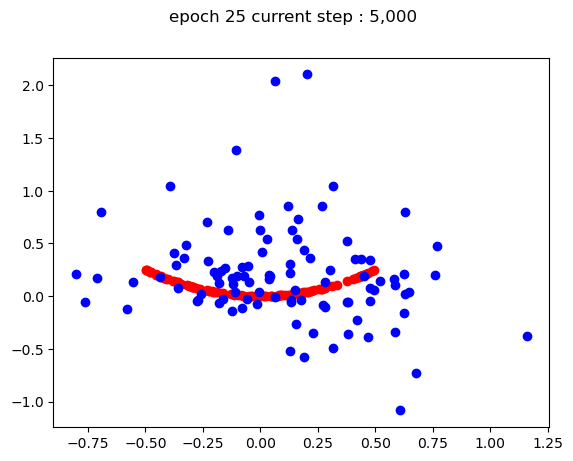


currentStep : 5,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6109,  1.1965]) y range : tensor([-0.9312,  1.5583]) max - min : tensor([1.8074, 2.4895])
Step 5,000: Generator loss: -0.2691751968674362, crtic loss: 0.02737812095170824
Memory usage (RSS): 354.875 MB


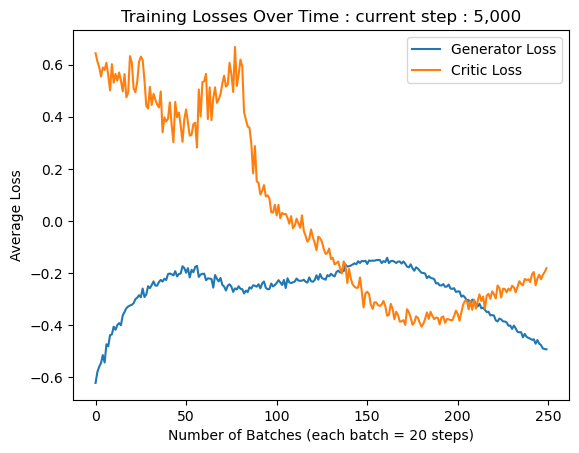

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch050.png


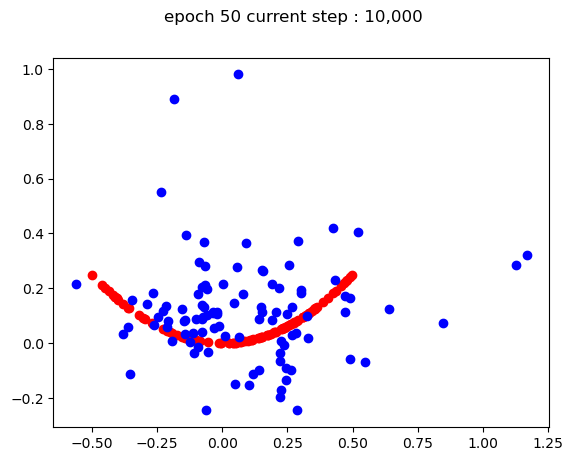


currentStep : 10,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5282,  1.0050]) y range : tensor([-0.2086,  0.6856]) max - min : tensor([1.5332, 0.8942])
Step 10,000: Generator loss: -0.6613745272576809, crtic loss: -0.1396536661440137
Memory usage (RSS): 358.71875 MB


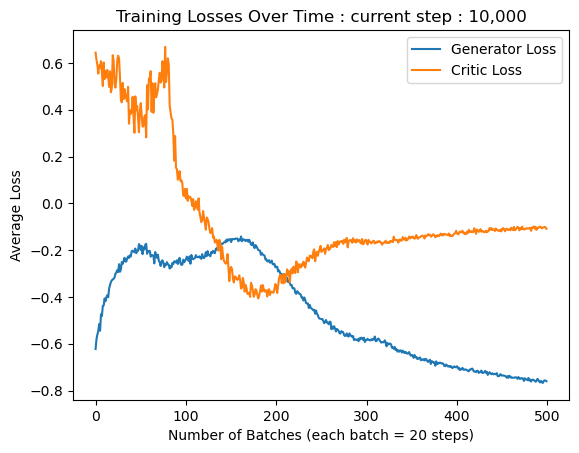

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch075.png


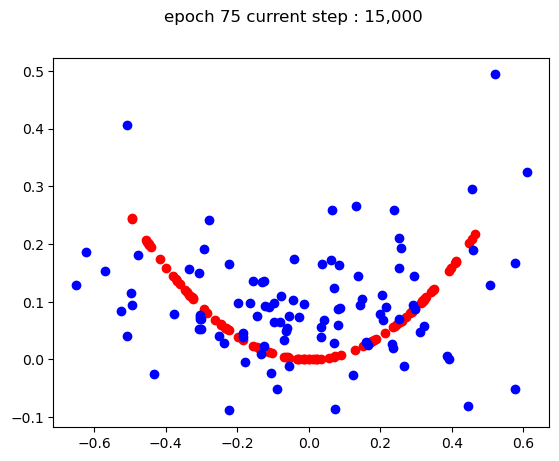


currentStep : 15,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5944,  0.4424]) y range : tensor([-0.1573,  0.4058]) max - min : tensor([1.0368, 0.5632])
Step 15,000: Generator loss: -0.7981280978798866, crtic loss: -0.08872948162183182
Memory usage (RSS): 362.6875 MB


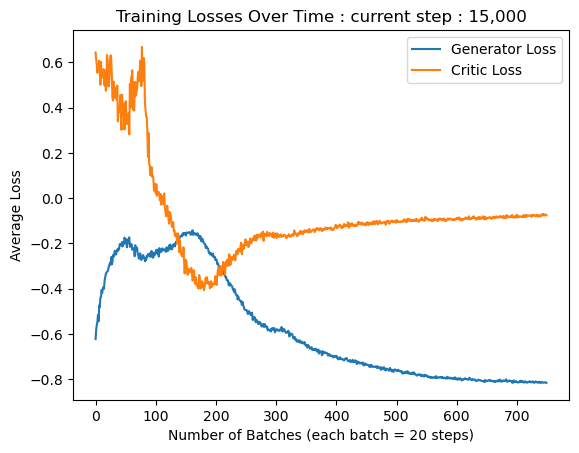

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch100.png


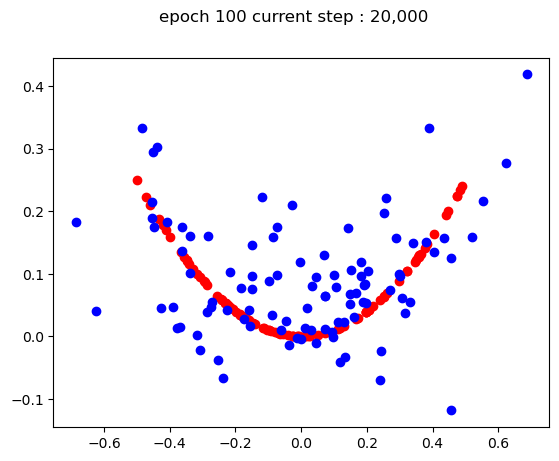


currentStep : 20,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.8204,  0.7128]) y range : tensor([-0.0811,  0.3938]) max - min : tensor([1.5332, 0.4749])
Step 20,000: Generator loss: -0.8238941362500191, crtic loss: -0.06327280106671129
Memory usage (RSS): 365.6875 MB


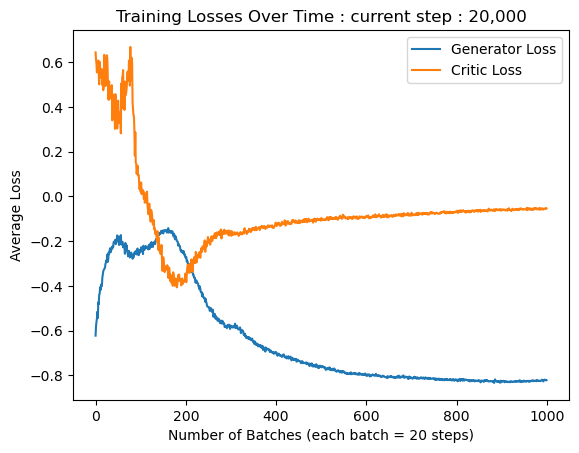

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch125.png


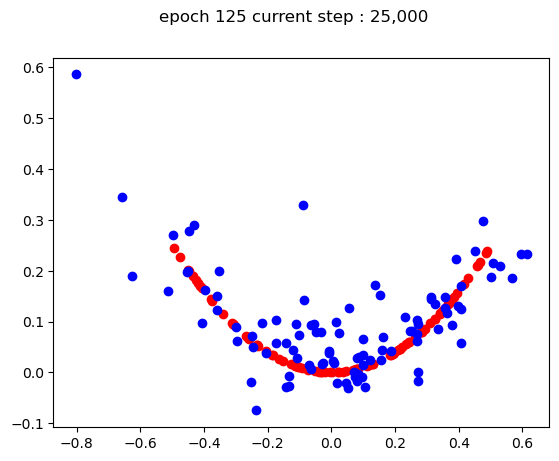


currentStep : 25,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6291,  0.9830]) y range : tensor([-0.0909,  0.3301]) max - min : tensor([1.6122, 0.4211])
Step 25,000: Generator loss: -0.8021719885468483, crtic loss: -0.04823084191843854
Memory usage (RSS): 366.09765625 MB


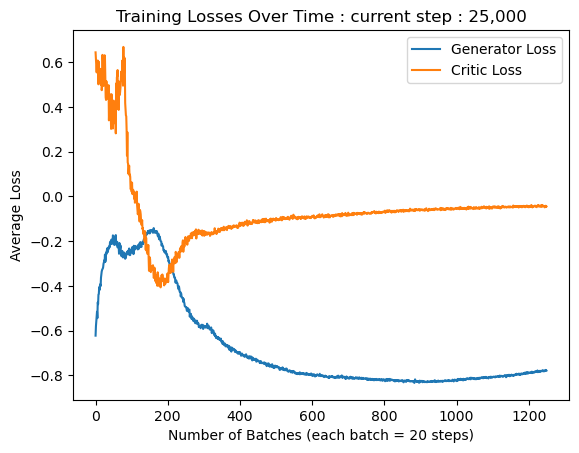

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch150.png


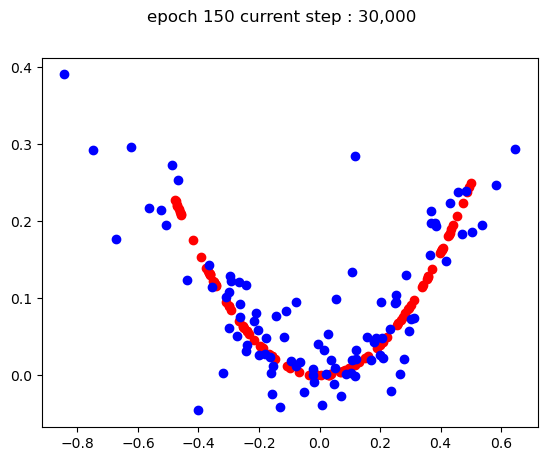


currentStep : 30,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5695,  0.7260]) y range : tensor([-0.0458,  0.3461]) max - min : tensor([1.2955, 0.3919])
Step 30,000: Generator loss: -0.7504512151360512, crtic loss: -0.04075962019905453
Memory usage (RSS): 366.34765625 MB


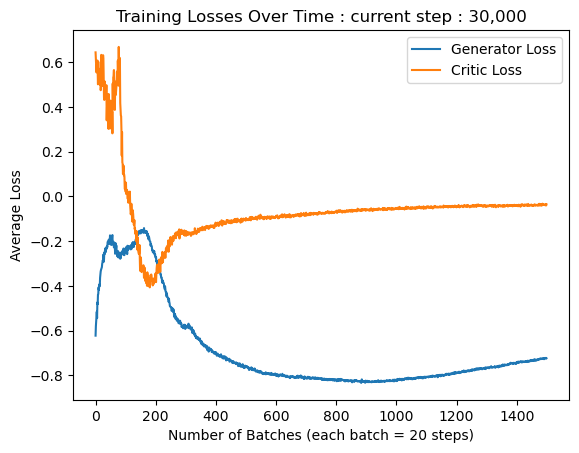

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch175.png


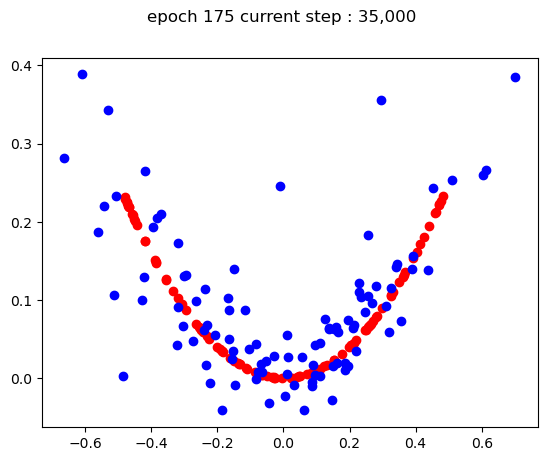


currentStep : 35,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6498,  0.6472]) y range : tensor([-0.0301,  0.3867]) max - min : tensor([1.2969, 0.4168])
Step 35,000: Generator loss: -0.7060191177487374, crtic loss: -0.03445332339132212
Memory usage (RSS): 366.73046875 MB


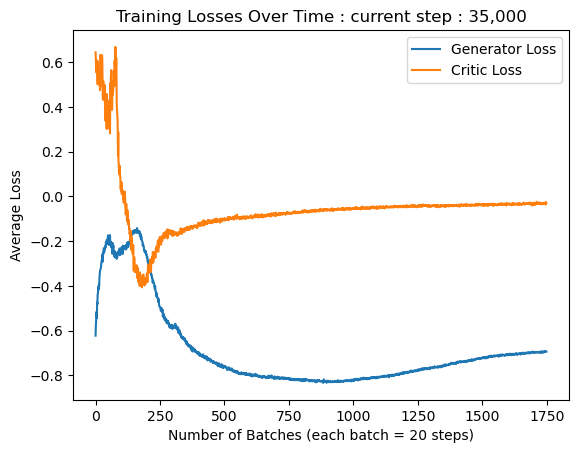

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch200.png


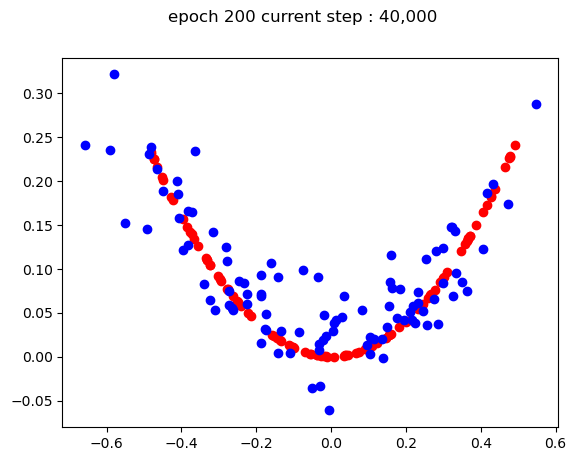


currentStep : 40,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5592,  0.7140]) y range : tensor([-0.0511,  0.3847]) max - min : tensor([1.2733, 0.4358])
Step 40,000: Generator loss: -0.6866110295534134, crtic loss: -0.02888656561423096
Memory usage (RSS): 369.23828125 MB


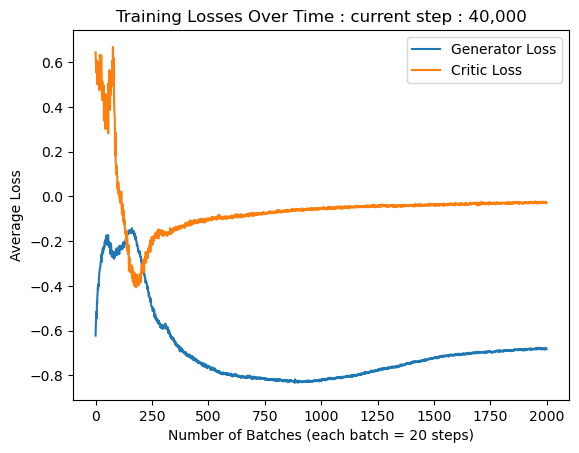

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch225.png


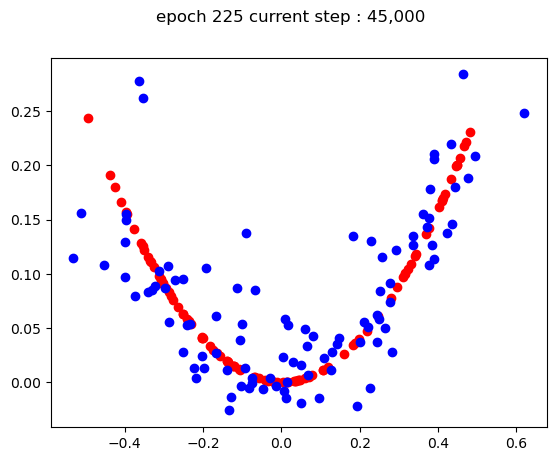


currentStep : 45,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6215,  0.5771]) y range : tensor([-0.0518,  0.2876]) max - min : tensor([1.1986, 0.3394])
Step 45,000: Generator loss: -0.6773863271474838, crtic loss: -0.02419889400120825
Memory usage (RSS): 372.70703125 MB


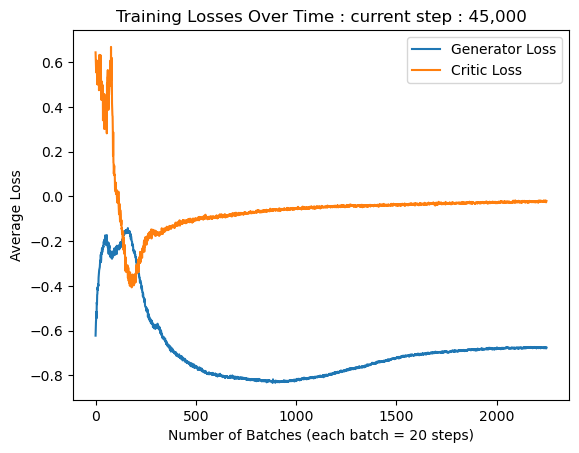

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch250.png


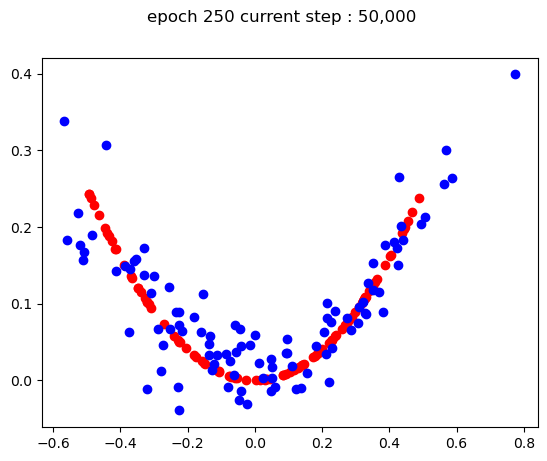


currentStep : 50,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.9207,  0.5963]) y range : tensor([-0.0299,  0.4448]) max - min : tensor([1.5171, 0.4747])
Step 50,000: Generator loss: -0.6773265397429467, crtic loss: -0.021014552017720397
Memory usage (RSS): 375.46875 MB


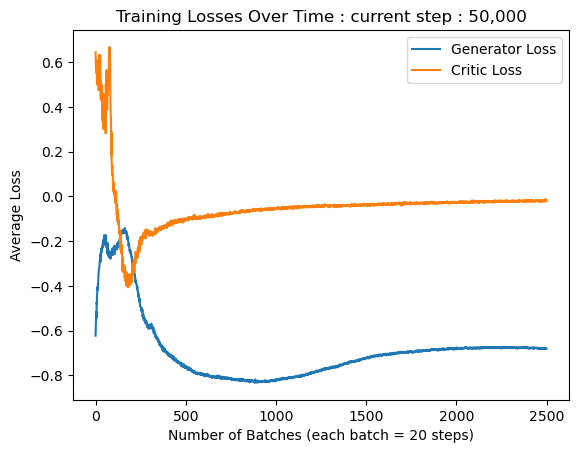

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch275.png


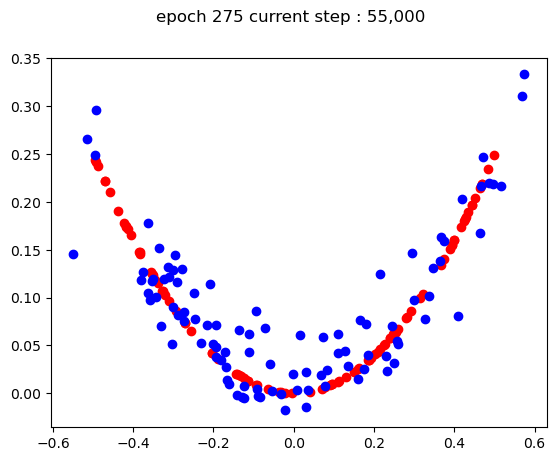


currentStep : 55,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5534,  0.5177]) y range : tensor([-0.0384,  0.2649]) max - min : tensor([1.0711, 0.3034])
Step 55,000: Generator loss: -0.6802751091718674, crtic loss: -0.01989072079737667
Memory usage (RSS): 376.53515625 MB


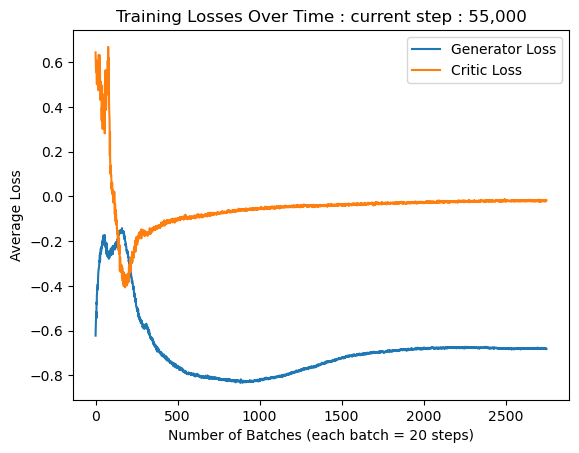

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch300.png


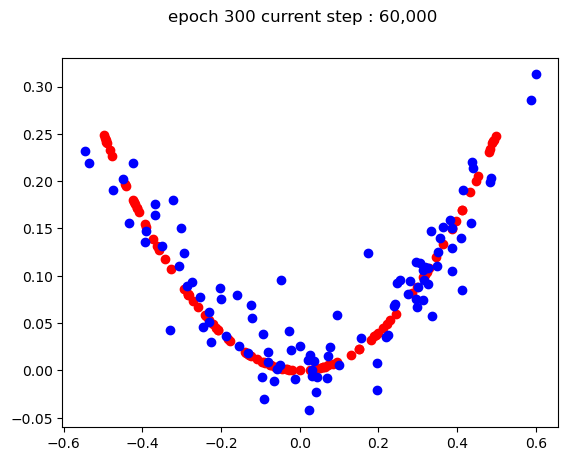


currentStep : 60,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4795,  0.5138]) y range : tensor([-0.0334,  0.2621]) max - min : tensor([0.9933, 0.2955])
Step 60,000: Generator loss: -0.6790354035854339, crtic loss: -0.01919242171477529
Memory usage (RSS): 379.61328125 MB


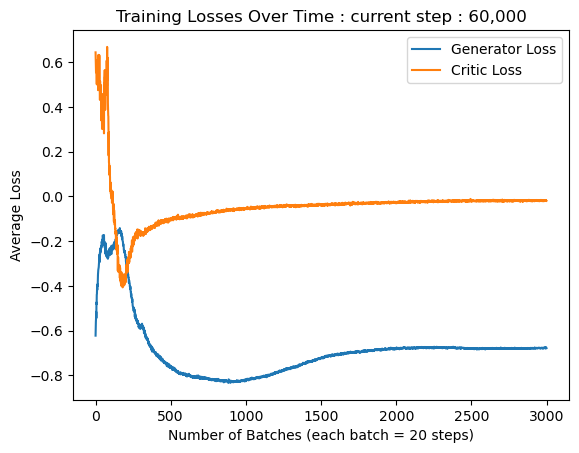

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch325.png


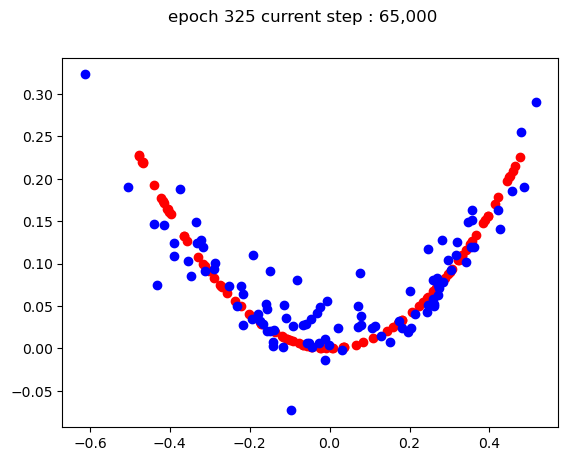


currentStep : 65,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7392,  0.5374]) y range : tensor([-0.0102,  0.4008]) max - min : tensor([1.2766, 0.4110])
Step 65,000: Generator loss: -0.677249707198143, crtic loss: -0.018795759678082506
Memory usage (RSS): 381.75 MB


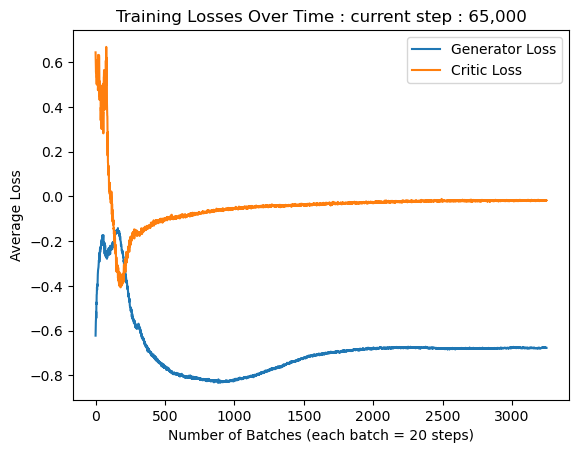

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch350.png


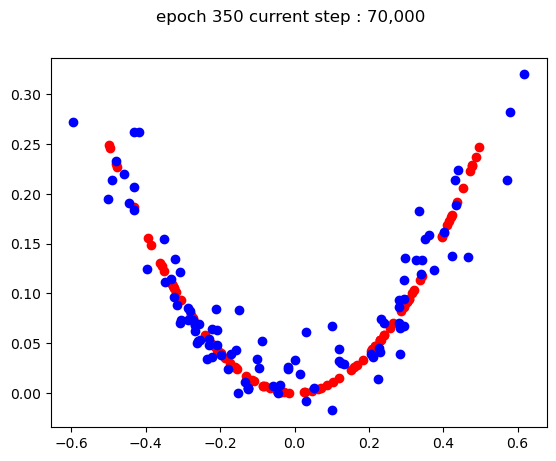


currentStep : 70,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5200,  0.5492]) y range : tensor([-0.0137,  0.2803]) max - min : tensor([1.0692, 0.2940])
Step 70,000: Generator loss: -0.6793134172201156, crtic loss: -0.017819462435496983
Memory usage (RSS): 383.48046875 MB


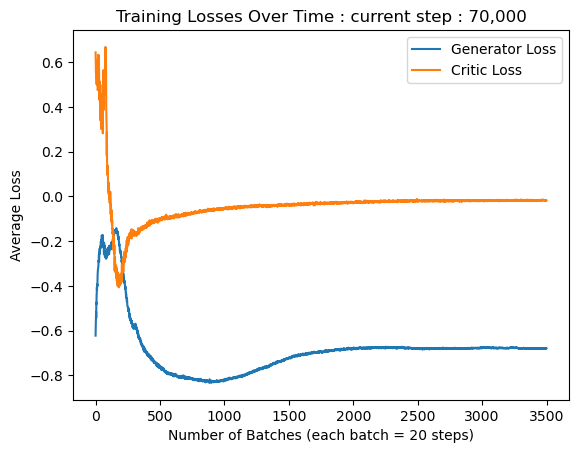

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch375.png


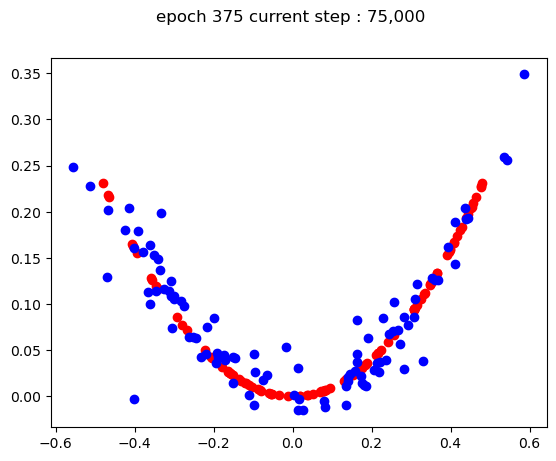


currentStep : 75,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4528,  0.5168]) y range : tensor([-0.0168,  0.2818]) max - min : tensor([0.9696, 0.2986])
Step 75,000: Generator loss: -0.6797358266472816, crtic loss: -0.017155250945696674
Memory usage (RSS): 387.16796875 MB


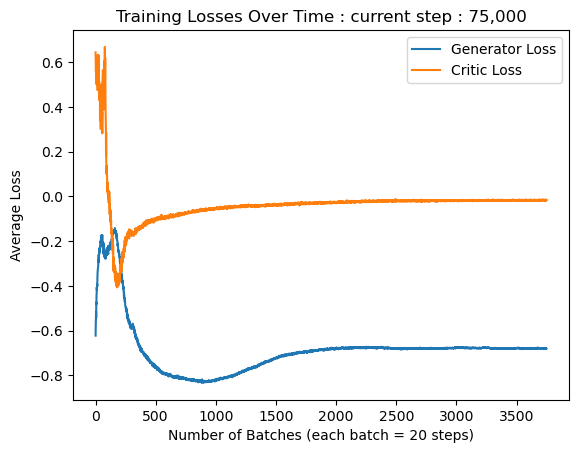

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch400.png


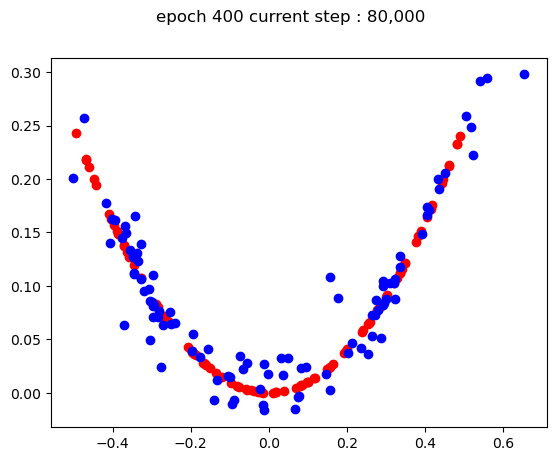


currentStep : 80,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7543,  0.5439]) y range : tensor([-0.0318,  0.3520]) max - min : tensor([1.2981, 0.3837])
Step 80,000: Generator loss: -0.6840552681922912, crtic loss: -0.016620510405655993
Memory usage (RSS): 390.56640625 MB


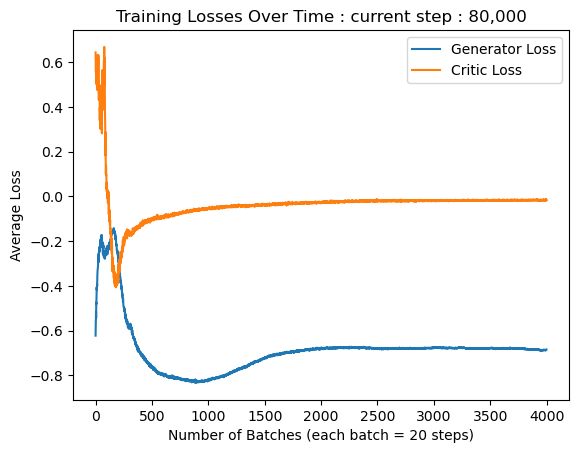

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch425.png


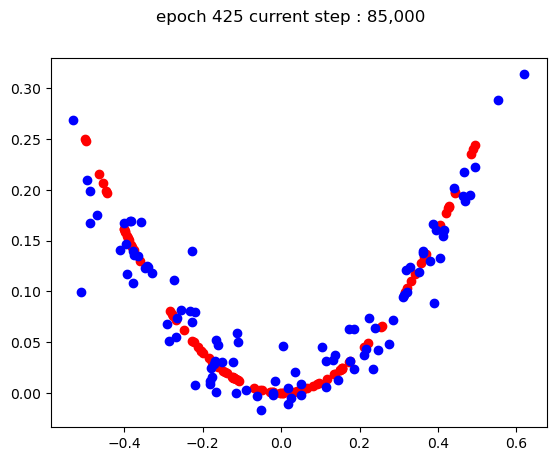


currentStep : 85,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4971,  0.6007]) y range : tensor([-0.0258,  0.3339]) max - min : tensor([1.0978, 0.3597])
Step 85,000: Generator loss: -0.68836539914608, crtic loss: -0.01622216433005411
Memory usage (RSS): 392.6953125 MB


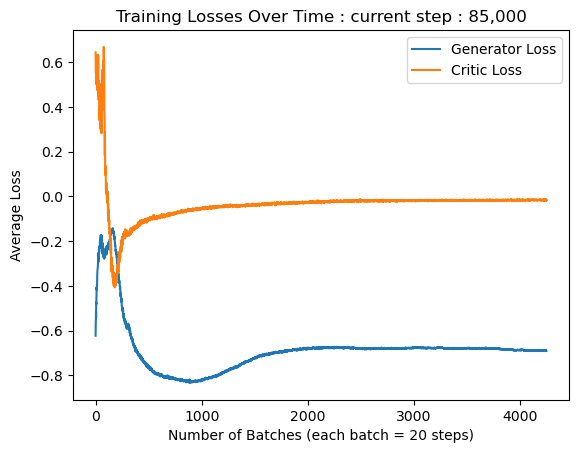

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch450.png


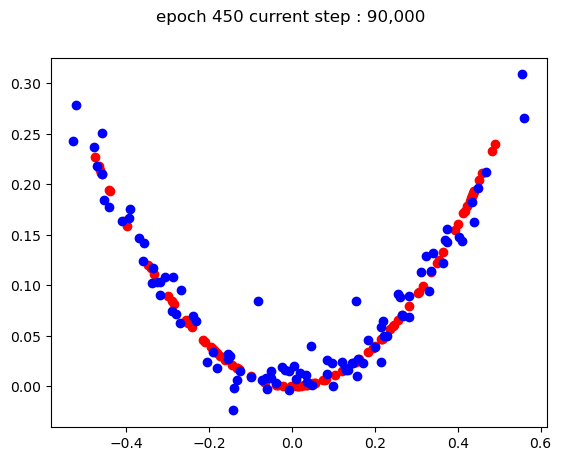


currentStep : 90,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5328,  0.5617]) y range : tensor([-0.0212,  0.2895]) max - min : tensor([1.0944, 0.3108])
Step 90,000: Generator loss: -0.6907752803444862, crtic loss: -0.015745394992776007
Memory usage (RSS): 397.45703125 MB


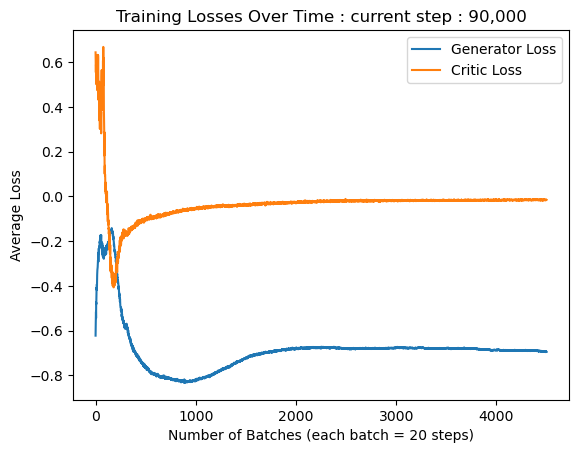

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch475.png


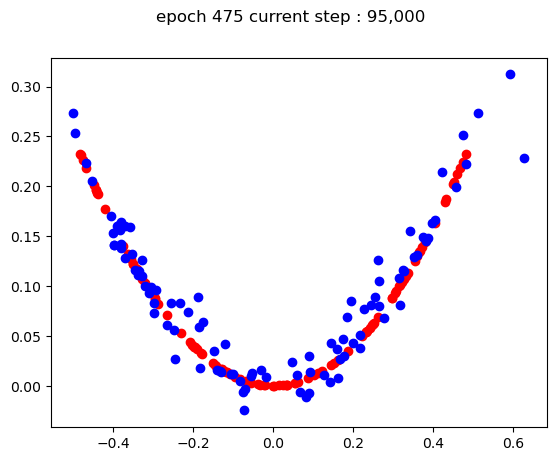


currentStep : 95,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5035,  0.4781]) y range : tensor([-0.0318,  0.2922]) max - min : tensor([0.9817, 0.3241])
Step 95,000: Generator loss: -0.6992200756192207, crtic loss: -0.015415245537899887
Memory usage (RSS): 400.4296875 MB


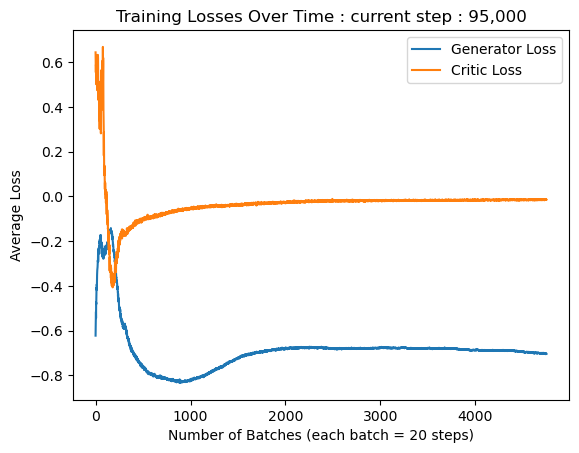

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch500.png


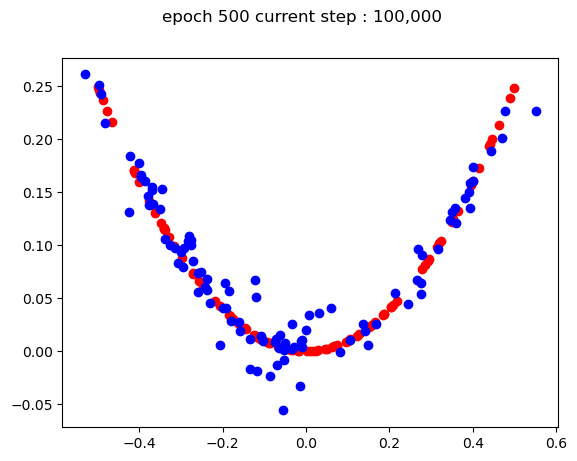


currentStep : 100,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5312,  0.7243]) y range : tensor([-0.0292,  0.3876]) max - min : tensor([1.2555, 0.4168])
finished
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch500.png


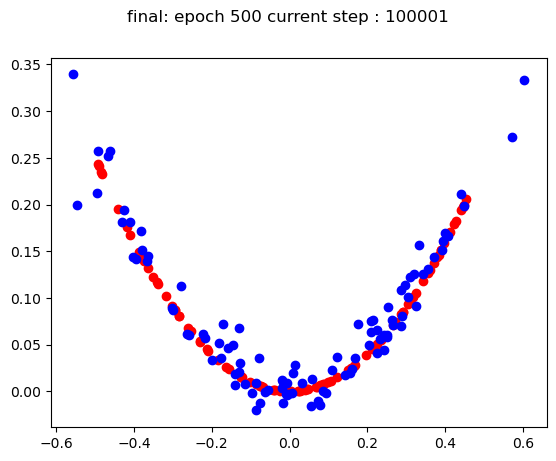

CPU times: user 28min 12s, sys: 25.5 s, total: 28min 37s
Wall time: 24min 11s


In [18]:
%%time

# reset state every time we run
currentStep = 0

# meanGeneratorLoss = 0
# meanDiscriminatorLoss = 0

generatorLosses = []
criticLosses = []

testGenerator= True # if true test generator weights are changing
error = False # default: no error


for epoch in range(nEpochs):

    #
    # add check point at end of each epoch    
    
    # tqdm provides progress bars for loops and iterables.
    # will choose implementaiton based on env. ie shell, juypter, ...
    # https://tqdm.github.io/
    # for i in tqdm( range(numBatchs) ) : 
    for i in range(numBatchs) : 
        # each epoch trains using all training samples where each sample is assigned to 
        # a random batch. After each patch update the model weights
        
        # if we where working with real data it is possible 
        # some batches are short. are < batchSize
        currentBatchSize = batchSize
        realSamples, realLabels = generateRealSamples( currentBatchSize )

        #################        
        ################# Update critic 
        #################        
        meanIterationCriticLoss = 0
        for _ in range( criticRepeats ):
            # update the critic multiple times every time you update the generator This helps 
            # prevent the generator from overpowering the critic. Sometimes, you might see the 
            # reverse, with the generator updated more times than the critic. This depends on 
            # architectural (e.g. the depth and width of the network) and algorithmic 
            # choices (e.g. which loss you're using).

            # Zero out the gradients before backpropagation
            criticOptimizer.zero_grad()
            
            # fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, currentBatchSize, device )
            # generate points in latent space
            noiseVector = generateLatentPoints(zDim, currentBatchSize)
            fakeSamples = generator( noiseVector )
            
            predictionsOnFakes = critic( fakeSamples )
            predictionsOnReal = critic( realSamples )
            
            epsilon = torch.rand( len(realSamples), 1, device=device, requires_grad=True )
            #print(f'aedwip epsilon.shape: {epsilon.shape}')
            #print(f'aedwip epsilon: {epsilon}')
            
            gradient = getGradient( critic, realSamples, fakeSamples.detach(), epsilon )
            gp = gradientPenalty( gradient )
            criticLoss = getCriticLoss( predictionsOnFakes, predictionsOnReal, gp, cLambda )
            
            # Keep track of the average critic loss in this batch
            meanIterationCriticLoss += criticLoss.item() / criticRepeats
            
            # Update gradients
            criticLoss.backward(retain_graph=True)
            
            # Update optimizer
            criticOptimizer.step()

        # concatenate the list items
        #print(f'aedwip meanIterationCriticLoss : {meanIterationCriticLoss}' )        
        criticLosses += [meanIterationCriticLoss]

        #################        
        ################# Update generator 
        ################# 
        meanIterationGeneratorLoss = 0
        for _ in range( generatorRepeats ):
            generatorOptimizer.zero_grad()
            # I think generateFakeSamples was preventing generator from updating
            #fakeSamples2, fakeLabels2  = generateFakeSamples( generator, zDim, currentBatchSize, device )
            noiseVector2 = generateLatentPoints(zDim, currentBatchSize)
            fakeSamples2 = generator( noiseVector2 )
            predictionsOnFakes2 = critic( fakeSamples2 )
            
            generatorLoss = getGeneratorLoss( predictionsOnFakes2 )
             # update the gradients
            generatorLoss.backward()
            
            # Update the weights
            generatorOptimizer.step()
            # Keep track of the average generators loss in this batch            
            meanIterationGeneratorLoss += generatorLoss.item() / generatorRepeats

           
    
            # Keep track of the average generator loss in this batch
        generatorLosses += [meanIterationGeneratorLoss]

        

        ### Visualization code ###
        if currentStep % displayStep == 0 and currentStep > 0:
            genMean = sum(generatorLosses[-displayStep:]) / displayStep
            criticMean = sum(criticLosses[-displayStep:]) / displayStep            
            msg = f'Step {currentStep:,}: Generator loss: {genMean}, crtic loss: {criticMean}'
            print( msg )

            # Get memory usage of the current process in bytes
            process = psutil.Process()
            memory_info = process.memory_info()
            rss_memory = memory_info.rss  # Resident Set Size (physical memory used)
            print("Memory usage (RSS):", rss_memory / (1024 * 1024), "MB")   
            
            #
            # plot learning curves
            # 
            stepBins = 20  # the number of step in each bin
            numExamples = (len(generatorLosses) // stepBins) * stepBins
            # print(f'aedwip len(generatorLosses) : {len(generatorLosses)}' )
            # print(f'aedwip numExamples : {numExamples}' )

            # create plots
            # x axis is the number of bings
            # y axis = averge loss for each bin
            plt.plot(
                range(numExamples // stepBins), 
                torch.Tensor(generatorLosses[:numExamples]).view(-1, stepBins).mean(1),
                label="Generator Loss"
            )            
            plt.plot(
                range(numExamples // stepBins), 
                torch.Tensor(criticLosses[:numExamples]).view(-1, stepBins).mean(1),
                label="Critic Loss"
            )
            
            plt.xlabel(f"Number of Batches (each batch = {stepBins} steps)")
            plt.ylabel("Average Loss")
            plt.title(f"Training Losses Over Time : current step : {currentStep:,}")

            plt.legend()
            plt.show()        
            
        currentStep += 1

        
        #if (epoch + 1) % displayQuotient == 0 and currentStep > 0:
        if currentStep % plotStep == 0 and currentStep > 0:
            title = f"epoch {epoch + 1:,} current step : {currentStep:,}"
            summarizePerformance(generator, zDim, imgOut, title)
            debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device)


print(f'finished')
title = f"final: epoch {epoch + 1} current step : {currentStep + 1} "
summarizePerformance(generator, zDim, imgOut, title)

In [19]:
debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device)


currentStep : 100,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5250,  0.5388]) y range : tensor([-0.0385,  0.2807]) max - min : tensor([1.0639, 0.3192])
